# Projeto Cascata Boost PFC + Inversor VSI Trifásico

Este notebook projeta a **cascata completa** de conversão AC→AC industrial:

```
   AC 220V_rms 60Hz  →  retificador  →  Boost PFC  →  DC bus 400V  →  3φ VSI  →  carga
   (rede mono)         (4 diodos)      (L+Q+D+Cdc)   (regulado)      (6 MOSFETs) (motor R Y)
```

Cobertura por estágio:

| Estágio | Função | Frequência | Tópico |
|---|---|---|---|
| Retificador | AC → DC pulsado | 2 × f_line | seleção diodo, perda condução |
| Boost PFC | shaping current + boost DC | 100 kHz | L, Q, D, controle PI corrente + PI tensão |
| DC bus | filtro 120 Hz + reservoir | — | Cdc dimensionado para ripple alvo |
| VSI 3φ | DC → 3φ AC | 16 kHz | SPWM, m_a, filtro LC, perdas SiC |

**Por que precisamos do PFC?**

Retificador de ponte alimentando cap eletrolítico **sem** PFC tem:
- THDi típico **80–120%** (corrente em pulsos estreitos)
- **PF ≈ 0.55–0.70**
- Não passa em IEC 61000-3-2 / EN 50160 para P > 75 W

PFC ativo (boost) força corrente AC a ser senoidal em fase com tensão:
- THDi **< 5%**
- PF **> 0.99**
- DC bus regulado ⇒ permite VSI operar em condições constantes

> **APIs usadas:** `add_sine_voltage_source`, `add_bridge_rectifier`,
> `add_three_phase_vsi`, mais componentes RLC/diodo/MOSFET.


In [1]:
from pathlib import Path
import sys

_root = Path.cwd()
_candidate_paths = []
for _ in range(6):
    for _rel in (('build-test', 'python'), ('build', 'python')):
        candidate = _root / _rel[0] / _rel[1]
        if candidate.is_dir():
            _candidate_paths.append(candidate)
    _root = _root.parent

_seen = set()
for candidate in _candidate_paths:
    cstr = str(candidate)
    if cstr in _seen:
        continue
    _seen.add(cstr)
    if cstr not in sys.path:
        sys.path.insert(0, cstr)

import numpy as np
import matplotlib.pyplot as plt
import pulsim as ps

print(f"Pulsim version: {ps.__version__}")


Pulsim version: 0.10.0a11


## 1. Especificações de Sistema

Drive industrial / inversor solar / UPS típico:

| Parâmetro | Valor | Comentário |
|---|---|---|
| V_ac (mono) | 220 V_rms | rede industrial BR (alt: 110V US, 230V EU) |
| f_line | 60 Hz | rede |
| V_dc (alvo) | 400 V | barramento DC após boost |
| P_out | 5 kW | carga 3φ |
| η_pfc (alvo) | ≥ 97% | SiC + design otimizado |
| η_vsi (alvo) | ≥ 97% | SiC + 16 kHz |
| η_total | ≥ 94% | cascata |
| f_sw_pfc | 100 kHz | SiC permite alta freq |
| f_sw_vsi | 16 kHz | acima do audível |
| THDi_ac (alvo) | ≤ 5% | classe A IEC 61000-3-2 |
| PF (alvo) | ≥ 0.99 | normas industriais |


In [2]:
# ============================================================
# ESPECIFICAÇÕES DO SISTEMA
# ============================================================

# Entrada AC
V_ac_rms      = 220.0     # rede mono industrial [V_rms]
V_ac_peak     = V_ac_rms * np.sqrt(2)
f_line        = 60.0      # frequência da rede [Hz]
omega_line    = 2*np.pi*f_line

# DC bus alvo (saída do PFC)
V_dc          = 400.0

# Carga
P_out         = 5000.0    # 5 kW total
V_line_out    = 230.0     # V_rms linha-linha 3φ
f_fund        = 60.0      # frequência fundamental de saída

# Switching
f_sw_pfc      = 100e3     # boost PFC com SiC
f_sw_vsi      = 16e3      # VSI

# Eficiência alvo
eta_pfc_target = 0.97
eta_vsi_target = 0.97
eta_total_min  = eta_pfc_target * eta_vsi_target

# Potências (cascade reverso: P_out → P_dc → P_ac)
P_dc_target   = P_out / eta_vsi_target            # entrada do VSI = saída do PFC
P_ac_target   = P_dc_target / eta_pfc_target      # entrada AC = entrada do PFC
I_ac_rms      = P_ac_target / V_ac_rms            # corrente AC nominal (PF=1)
I_dc_avg      = P_dc_target / V_dc                # DC bus nominal

print("="*60)
print("ESPECIFICAÇÕES — CASCATA AC → DC → 3φ AC")
print("="*60)
print(f"AC input:        {V_ac_rms} V_rms @ {f_line} Hz  (peak {V_ac_peak:.0f} V)")
print(f"DC bus:          {V_dc} V regulado")
print(f"AC output:       {V_line_out} V_rms (linha-linha 3φ)")
print()
print(f"Potência:        P_out = {P_out/1e3:.1f} kW")
print(f"Cascata:         η_pfc·η_vsi ≥ {eta_total_min*100:.1f}%")
print(f"  → P_dc bus  = {P_dc_target/1e3:.2f} kW")
print(f"  → P_ac in   = {P_ac_target/1e3:.2f} kW")
print(f"  → I_ac_rms  = {I_ac_rms:.2f} A  (com PF=1; sem PFC seria ~{I_ac_rms/0.6:.1f} A)")
print(f"  → I_dc_avg  = {I_dc_avg:.2f} A")
print()
print(f"Switching:       f_sw_pfc = {f_sw_pfc/1e3:.0f} kHz, f_sw_vsi = {f_sw_vsi/1e3:.0f} kHz")


ESPECIFICAÇÕES — CASCATA AC → DC → 3φ AC
AC input:        220.0 V_rms @ 60.0 Hz  (peak 311 V)
DC bus:          400.0 V regulado
AC output:       230.0 V_rms (linha-linha 3φ)

Potência:        P_out = 5.0 kW
Cascata:         η_pfc·η_vsi ≥ 94.1%
  → P_dc bus  = 5.15 kW
  → P_ac in   = 5.31 kW
  → I_ac_rms  = 24.15 A  (com PF=1; sem PFC seria ~40.3 A)
  → I_dc_avg  = 12.89 A

Switching:       f_sw_pfc = 100 kHz, f_sw_vsi = 16 kHz


## 2. Retificador de Entrada (Ponte de 4 Diodos)

Para um boost PFC mono, usa-se ponte de diodos full-wave que produz
`|V_ac(t)|` (sempre positivo, 2×f_line Hz). O boost converte essa
forma pulsada em `V_dc` regulado.

### Stress nos diodos
- **V_R_max** ≥ V_ac_peak (= 311 V) → use 600 V de margem
- **I_F_avg** = I_ac_avg / 2 = (2/π) · I_ac_peak / 2
- **I_F_rms** = I_ac_rms / √2

Cada diodo conduz metade do ciclo (alternando pares D1/D3 ↔ D2/D4).

> Pulsim: `add_bridge_rectifier(name, ac_a, ac_b, dc_pos, dc_neg, RealisticDiodeParams)`
> monta os 4 diodos e nomeia-os `<name>__D1..D4` para
> análise de perdas por diodo.


In [3]:
# ============================================================
# DIMENSIONAMENTO DOS DIODOS DA PONTE
# ============================================================

I_ac_peak = I_ac_rms * np.sqrt(2)
I_diode_avg = I_ac_peak / np.pi             # média por diodo (metade do ciclo)
I_diode_rms = I_ac_rms / np.sqrt(2)         # rms por diodo

V_R_margin = 2.0                            # 2× V_pk para spikes de comutação
V_R_required = V_ac_peak * V_R_margin

print("STRESS NOS DIODOS DA PONTE (cada um dos 4)")
print("="*50)
print(f"  V_R_max necessário:  ≥ {V_R_required:.0f} V  (peak AC × {V_R_margin})")
print(f"  I_F_avg por diodo:   {I_diode_avg:.2f} A")
print(f"  I_F_rms por diodo:   {I_diode_rms:.2f} A")
print()
print("Recomendação: ultra-fast 600V/30A (e.g., STTH3006, GBJ3506)")
print("  V_F0 típico = 0.85V @ 25°C  →  P_cond ≈ V_F0 · I_avg")

# Perdas estimadas por diodo
V_F0_diode = 0.85
P_cond_diode = V_F0_diode * I_diode_avg
P_cond_bridge = 4 * P_cond_diode
print(f"\n  P_cond por diodo:    {P_cond_diode:.2f} W")
print(f"  P_cond bridge total: {P_cond_bridge:.2f} W")


STRESS NOS DIODOS DA PONTE (cada um dos 4)
  V_R_max necessário:  ≥ 622 V  (peak AC × 2.0)
  I_F_avg por diodo:   10.87 A
  I_F_rms por diodo:   17.08 A

Recomendação: ultra-fast 600V/30A (e.g., STTH3006, GBJ3506)
  V_F0 típico = 0.85V @ 25°C  →  P_cond ≈ V_F0 · I_avg

  P_cond por diodo:    9.24 W
  P_cond bridge total: 36.97 W


## 3. Estágio Boost PFC — Topologia + Componentes

```
   |V_ac(t)|  →  L_pfc  →  +─── D_boost ──→ V_dc
                            |
                          Q_pfc (MOSFET LS, switching @ 100 kHz)
                            |
                           gnd
```

O boost opera em **CCM** (Continuous Conduction Mode) — corrente do indutor
nunca chega a zero. O conversor é controlado para fazer `I_L(t)` seguir
um *gabarito senoidal* proporcional a `|V_ac(t)|`, resultando em corrente
AC senoidal em fase com a tensão.

### Razão de boost
$$D = 1 - \frac{V_{in}(t)}{V_{dc}}$$

`V_in(t) = |V_ac(t)|` varia de 0 a V_pk. Logo:
- D varia de **0.22 a 1.0** durante cada meio-ciclo (com V_pk=311V, V_dc=400V)
- Próximo do zero-crossing, D→1 (boost forte)
- Próximo do pico, D≈0.22 (boost suave)

### Sizing do indutor PFC

Para ripple de corrente alvo `ΔI_L ≤ 20% · I_L_pk`:
$$L_{pfc} \geq \frac{V_{pk}^2}{4 \cdot V_{dc} \cdot f_{sw} \cdot \Delta I_L}$$

(usando ponto pior: V_in = V_pk/2 onde ripple é máximo)


In [4]:
# ============================================================
# SIZING DO BOOST PFC
# ============================================================

# Corrente no indutor (mesma do AC pq não há cap antes do boost)
I_L_avg_pk = I_ac_peak                    # pico da senoide retificada
I_L_rms    = I_ac_rms                     # corrente RMS no indutor

# Ripple de corrente alvo: 20% do pico
delta_IL_pct = 0.20
delta_IL = delta_IL_pct * I_L_avg_pk

# Indutor mínimo (pior caso ripple: V_in = V_dc/2)
L_pfc_min = V_dc / (4.0 * f_sw_pfc * delta_IL)
L_pfc = 500e-6     # 500 µH comercial (toroidal pó de ferro)

# Ripple resultante
delta_IL_real = V_dc / (4.0 * f_sw_pfc * L_pfc)

print("INDUTOR DO BOOST PFC")
print("="*50)
print(f"  I_L pico:           {I_L_avg_pk:.2f} A")
print(f"  I_L rms:            {I_L_rms:.2f} A")
print(f"  ΔI_L alvo (20%):    {delta_IL:.2f} A")
print(f"  L_pfc mínimo:       {L_pfc_min*1e6:.0f} µH")
print(f"  L_pfc selecionado:  {L_pfc*1e6:.0f} µH (comercial)")
print(f"  ΔI_L real:          {delta_IL_real:.2f} A  ({delta_IL_real/I_L_avg_pk*100:.1f}%)")

# Energia e tamanho aproximado
E_L = 0.5 * L_pfc * (I_L_avg_pk + delta_IL_real/2)**2
print(f"  Energia armazenada: {E_L*1e3:.1f} mJ  (define tamanho do núcleo)")

# Switch PFC: V_DS deve aguentar V_dc + spike
V_Q_max_required = V_dc * 1.5            # margem 50%
I_Q_rms = I_L_rms * np.sqrt(1.0 - 0.5)   # duty médio ~50% (regra prática)
print()
print("MOSFET DO BOOST (low-side)")
print("="*50)
print(f"  V_DS necessário:    ≥ {V_Q_max_required:.0f} V  →  SiC 650V ou 1200V")
print(f"  I_D_rms estimado:   {I_Q_rms:.2f} A  →  use 30A para folga térmica")

# Diodo do boost: SiC Schottky obrigatório (sem Qrr)
print()
print("DIODO DO BOOST (high-side, output)")
print("="*50)
print(f"  V_R necessário:     ≥ {V_dc * 1.5:.0f} V  →  SiC Schottky 650V/30A")
print(f"  I_F_avg:            {I_dc_avg:.2f} A")
print(f"  Qrr = 0 (Schottky) — essencial para minimizar perda de turn-on do MOSFET")


INDUTOR DO BOOST PFC
  I_L pico:           34.16 A
  I_L rms:            24.15 A
  ΔI_L alvo (20%):    6.83 A
  L_pfc mínimo:       146 µH
  L_pfc selecionado:  500 µH (comercial)
  ΔI_L real:          2.00 A  (5.9%)
  Energia armazenada: 309.1 mJ  (define tamanho do núcleo)

MOSFET DO BOOST (low-side)
  V_DS necessário:    ≥ 600 V  →  SiC 650V ou 1200V
  I_D_rms estimado:   17.08 A  →  use 30A para folga térmica

DIODO DO BOOST (high-side, output)
  V_R necessário:     ≥ 600 V  →  SiC Schottky 650V/30A
  I_F_avg:            12.89 A
  Qrr = 0 (Schottky) — essencial para minimizar perda de turn-on do MOSFET


### Cap DC-link

O cap do barramento precisa absorver:
1. **Ripple de 2·f_line = 120 Hz** vindo do retificador + PFC (potência pulsa em 2·f_line)
2. **Ripple de f_sw_vsi = 16 kHz** drenado pelo VSI (cap eletrolítico tem ESR ↑ neste range — usar cap filme em paralelo)
3. **Reservoir** para hold-up time em queda momentânea

Ripple de 120 Hz dominante:
$$\Delta V_{dc, 120Hz} = \frac{P_{out}}{2\pi \cdot 2 \cdot f_{line} \cdot C_{dc} \cdot V_{dc}}$$


In [5]:
# ============================================================
# CAP DO DC-LINK
# ============================================================

delta_V_dc_pct = 0.04       # 4% ripple alvo no DC bus (típico p/ PFC)
delta_V_dc     = delta_V_dc_pct * V_dc

# Cap mínimo para limitar ripple de 120 Hz
C_dc_min = P_out / (2 * np.pi * 2*f_line * delta_V_dc * V_dc)

# Hold-up: manter V_dc ≥ V_dc_min por 10 ms (1 ciclo de linha)
V_dc_min_holdup = 320.0     # antes de PFC perder controle
t_holdup = 10e-3
C_dc_holdup = 2 * P_out * t_holdup / (V_dc**2 - V_dc_min_holdup**2)

# Pega o maior
C_dc_required = max(C_dc_min, C_dc_holdup)
C_dc = 1500e-6              # 1500 µF eletrolítico 450V

# Ripple real
delta_V_dc_real = P_out / (2 * np.pi * 2*f_line * C_dc * V_dc)

print("CAP DC-LINK")
print("="*50)
print(f"  Ripple alvo 120Hz:    {delta_V_dc:.1f} V ({delta_V_dc_pct*100:.0f}%)")
print(f"  C_dc mínimo (ripple): {C_dc_min*1e6:.0f} µF")
print(f"  C_dc mínimo (holdup): {C_dc_holdup*1e6:.0f} µF (10 ms @ V_min={V_dc_min_holdup}V)")
print(f"  C_dc selecionado:     {C_dc*1e6:.0f} µF eletrolítico 450V")
print(f"  Ripple real 120Hz:    {delta_V_dc_real:.1f} V ({delta_V_dc_real/V_dc*100:.2f}%)")
print()
print("  Recomendação: 1500µF eletrolítico ‖ 4.7µF filme polipropileno")
print("  (filme cuida do ripple de 16kHz onde o eletrolítico tem ESR alto)")


CAP DC-LINK
  Ripple alvo 120Hz:    16.0 V (4%)
  C_dc mínimo (ripple): 1036 µF
  C_dc mínimo (holdup): 1736 µF (10 ms @ V_min=320.0V)
  C_dc selecionado:     1500 µF eletrolítico 450V
  Ripple real 120Hz:    11.1 V (2.76%)

  Recomendação: 1500µF eletrolítico ‖ 4.7µF filme polipropileno
  (filme cuida do ripple de 16kHz onde o eletrolítico tem ESR alto)


## 4. Controle PFC — Loop Cascateado

PFC ativo precisa de **dois loops** simultâneos:

### Loop interno (corrente, rápido)
- **Sense:** corrente do indutor `I_L(t)`
- **Reference:** gabarito senoidal `I_ref(t) = K · |sin(ωt)|`
- **Plant:** boost com `V_ac(t) → I_L(t)`
- **fc:** ~10 kHz (acima de 2·f_line, abaixo de f_sw/10)
- **Output:** duty cycle D(t)

### Loop externo (tensão, lento)
- **Sense:** V_dc (com filtro p/ rejeitar 120 Hz)
- **Reference:** V_dc_target = 400 V
- **Plant:** I_L_amplitude → V_dc (lenta, dominada por C_dc)
- **fc:** **~15 Hz** (deve ser MUITO abaixo de 120 Hz para não realimentar o ripple)
- **Output:** amplitude do gabarito de corrente K

A separação de bandas é crítica: fc_outer << 2·f_line << fc_inner

> Modulação típica: o duty é calculado em cada ciclo de switching como
> `D(t) = 1 - V_in(t)/V_dc_measured`, e o erro `I_L - I_ref(t)` modula
> o termo aditivo via PI. Essa estrutura é o **average current mode control (ACMC)**.


In [6]:
# ============================================================
# DESIGN DOS CONTROLADORES PFC
# ============================================================

# === Loop interno (corrente) ===
# Plant: G_id(s) = V_dc / (s · L_pfc)  — modelo small-signal averaged
# Crossover alvo: 10 kHz (limita ripple de switching no comando)
fc_inner = 10e3
omega_c_inner = 2*np.pi*fc_inner

# PI: zero em fc/5 para boost de fase, ganho para hit fc_inner
fz_pi_inner = fc_inner / 5
# Em fc_inner: |Kp · (1 + 1/(jωc·τ_pi))| · |V_dc/(jωc·L_pfc)| = 1
#   ≈ Kp · V_dc / (ωc · L_pfc) = 1  (ignorando o termo do zero acima de fz)
Kp_i = omega_c_inner * L_pfc / V_dc
Ki_i = Kp_i * 2*np.pi*fz_pi_inner

print("LOOP INTERNO (CORRENTE)")
print("="*50)
print(f"  fc alvo:        {fc_inner/1e3:.1f} kHz")
print(f"  fz PI:          {fz_pi_inner/1e3:.2f} kHz")
print(f"  Kp_i:           {Kp_i:.5f}  [V/A]")
print(f"  Ki_i:           {Ki_i:.3f}  [V/(A·s)]")

# === Loop externo (tensão) ===
# Plant: G_v(s) ≈ V_ac_rms / (2 · V_dc · s · C_dc)  — pequena pertubação
fc_outer = 15.0             # bem abaixo de 120 Hz
omega_c_outer = 2*np.pi*fc_outer
fz_pi_outer = fc_outer / 10
Kp_v = (2 * V_dc * C_dc * omega_c_outer) / V_ac_rms
Ki_v = Kp_v * 2*np.pi*fz_pi_outer

print()
print("LOOP EXTERNO (TENSÃO)")
print("="*50)
print(f"  fc alvo:        {fc_outer:.1f} Hz  (rejeição de {2*f_line:.0f}Hz: {20*np.log10(fc_outer/(2*f_line)):.0f} dB)")
print(f"  fz PI:          {fz_pi_outer:.2f} Hz")
print(f"  Kp_v:           {Kp_v:.5f}  [A_pk/V]")
print(f"  Ki_v:           {Ki_v:.5f}  [A_pk/(V·s)]")

# Verificar separação de bandas
print()
print("SEPARAÇÃO DE BANDAS (essencial p/ estabilidade)")
print("="*50)
print(f"  fc_outer ({fc_outer:.0f}Hz)  <<  2·f_line ({2*f_line:.0f}Hz)  <<  fc_inner ({fc_inner/1e3:.0f}kHz)  <<  f_sw ({f_sw_pfc/1e3:.0f}kHz)")
print(f"     fator {2*f_line/fc_outer:.1f}×                  fator {fc_inner/(2*f_line):.0f}×              fator {f_sw_pfc/fc_inner:.0f}×")


LOOP INTERNO (CORRENTE)
  fc alvo:        10.0 kHz
  fz PI:          2.00 kHz
  Kp_i:           0.07854  [V/A]
  Ki_i:           986.960  [V/(A·s)]

LOOP EXTERNO (TENSÃO)
  fc alvo:        15.0 Hz  (rejeição de 120Hz: -18 dB)
  fz PI:          1.50 Hz
  Kp_v:           0.51408  [A_pk/V]
  Ki_v:           4.84508  [A_pk/(V·s)]

SEPARAÇÃO DE BANDAS (essencial p/ estabilidade)
  fc_outer (15Hz)  <<  2·f_line (120Hz)  <<  fc_inner (10kHz)  <<  f_sw (100kHz)
     fator 8.0×                  fator 83×              fator 10×


## 5. Estágio VSI Trifásico — Recap

(Para o tratamento completo, ver `vsi_inverter_design.ipynb`)

| Parâmetro | Valor |
|---|---|
| V_dc | 400 V (do PFC) |
| V_line out | 230 V_rms |
| f_sw | 16 kHz |
| m_a SPWM | 0.94 |
| Switches | 6 × SiC MOSFET 1200V/30A |
| Modulação | SPWM com índice 0.94 |
| Filtro | LC 2.5mH + 4.7µF/fase (fc≈1.5kHz) |


In [7]:
# ============================================================
# VSI STAGE — PARÂMETROS COMPACTOS
# ============================================================

# Modulação para hit 230V_rms com V_dc=400V via SPWM
m_a_vsi = (V_line_out * np.sqrt(2)) / (np.sqrt(3)/2 * V_dc)
print(f"Modulação VSI:       m_a = {m_a_vsi:.3f}  (SPWM)")

# Corrente RMS por fase do motor (carga Y)
S_load = P_out / 0.85    # cos φ ~ 0.85 motor
I_out_rms = S_load / (np.sqrt(3) * V_line_out)
R_load_phase = V_line_out**2 / P_out      # Y connection

print(f"Corrente RMS/fase:   {I_out_rms:.2f} A")
print(f"R load por fase (Y): {R_load_phase:.2f} Ω")

# Filtro LC (do projeto vsi_inverter_design)
L_f = 2.5e-3
C_f = 4.7e-6
print(f"Filtro LC:           L={L_f*1e3:.1f}mH + C={C_f*1e6:.1f}µF/fase")


Modulação VSI:       m_a = 0.939  (SPWM)
Corrente RMS/fase:   14.77 A
R load por fase (Y): 10.58 Ω
Filtro LC:           L=2.5mH + C=4.7µF/fase


## 6. Perdas + Eficiência da Cascata

### Estágio PFC
- **Bridge:** 4 × (V_F0 · I_avg_diode)
- **MOSFET PFC:** P_cond + P_sw
- **Diodo boost (Schottky):** V_F · I_avg_diode (Qrr = 0)
- **Indutor PFC:** I_L_rms² · DCR

### Estágio VSI
- **6 MOSFETs:** P_cond + P_sw + P_gate + P_coss (cada)
- **ESR Cdc:** I_cap_rms² · ESR
- **Indutores LC saída:** 3 × I_rms² · DCR


In [8]:
# ============================================================
# CASCATA DE PERDAS
# ============================================================

# --- PFC stage ---
# Bridge (4 diodos)
P_bridge = 4 * V_F0_diode * I_diode_avg

# MOSFET PFC: R_DS_on = 100 mΩ @ T_j=125°C, E_on+E_off ≈ 100µJ @ 400V/15A
R_DS_on_pfc = 100e-3
P_cond_Q_pfc = I_Q_rms**2 * R_DS_on_pfc
E_sw_pfc = 100e-6                                 # escalado para 400V/I_pk
P_sw_Q_pfc = E_sw_pfc * f_sw_pfc * (I_L_avg_pk / 15.0)
P_Q_pfc = P_cond_Q_pfc + P_sw_Q_pfc

# Diodo boost (SiC Schottky, V_F=1.5V típico, Qrr=0)
V_F_schottky = 1.5
P_D_boost = V_F_schottky * I_dc_avg

# Indutor PFC (DCR 30 mΩ típico p/ 500µH 25A)
DCR_pfc = 30e-3
P_L_pfc = I_L_rms**2 * DCR_pfc

P_pfc_total = P_bridge + P_Q_pfc + P_D_boost + P_L_pfc

# --- VSI stage (do design vsi_inverter_design) ---
R_DS_on_vsi = 150e-3
I_switch_rms = I_out_rms / np.sqrt(2)
P_cond_vsi_per = I_switch_rms**2 * R_DS_on_vsi
P_sw_vsi_per = 4.5                                # estimado do notebook anterior
P_vsi_mosfets = 6 * (P_cond_vsi_per + P_sw_vsi_per)
P_vsi_inductor = 3 * I_out_rms**2 * 50e-3         # 50 mΩ DCR por choke
P_vsi_total = P_vsi_mosfets + P_vsi_inductor

# --- Cascade ---
P_in = P_out + P_pfc_total + P_vsi_total
eta_pfc = (P_dc_target) / (P_dc_target + P_pfc_total)
eta_vsi = P_out / (P_out + P_vsi_total)
eta_cascade = P_out / P_in

print("CASCATA DE PERDAS")
print("="*60)
print(f"PFC ({P_dc_target/1e3:.2f} kW DC bus):")
print(f"  Bridge (4 diodos):       {P_bridge:6.2f} W")
print(f"  MOSFET PFC:              {P_Q_pfc:6.2f} W  (cond {P_cond_Q_pfc:.1f} + sw {P_sw_Q_pfc:.1f})")
print(f"  Diodo Schottky boost:    {P_D_boost:6.2f} W")
print(f"  Indutor PFC (DCR):       {P_L_pfc:6.2f} W")
print(f"  Subtotal PFC:            {P_pfc_total:6.2f} W   →  η_pfc = {eta_pfc*100:.2f}%")
print()
print(f"VSI 3φ ({P_out/1e3:.1f} kW out):")
print(f"  6 MOSFETs:               {P_vsi_mosfets:6.2f} W")
print(f"  3 Indutores filtro:      {P_vsi_inductor:6.2f} W")
print(f"  Subtotal VSI:            {P_vsi_total:6.2f} W   →  η_vsi = {eta_vsi*100:.2f}%")
print()
print(f"{'-'*60}")
print(f"P_in cascata:              {P_in:6.0f} W")
print(f"P_out cascata:             {P_out:6.0f} W")
print(f"PERDA TOTAL:               {P_pfc_total+P_vsi_total:6.0f} W")
print(f"η CASCATA:                 {eta_cascade*100:.2f}%   (alvo {eta_total_min*100:.1f}%)")
print(f"  {'✓ acima do alvo' if eta_cascade >= eta_total_min else '⚠ abaixo do alvo'}")


CASCATA DE PERDAS
PFC (5.15 kW DC bus):
  Bridge (4 diodos):        36.97 W
  MOSFET PFC:               51.95 W  (cond 29.2 + sw 22.8)
  Diodo Schottky boost:     19.33 W
  Indutor PFC (DCR):        17.50 W
  Subtotal PFC:            125.75 W   →  η_pfc = 97.62%

VSI 3φ (5.0 kW out):
  6 MOSFETs:               125.12 W
  3 Indutores filtro:       32.71 W
  Subtotal VSI:            157.82 W   →  η_vsi = 96.94%

------------------------------------------------------------
P_in cascata:                5284 W
P_out cascata:               5000 W
PERDA TOTAL:                  284 W
η CASCATA:                 94.63%   (alvo 94.1%)
  ✓ acima do alvo


## 7. Análise Térmica — Cascata

Cada switch precisa ter `T_j ≤ 125°C` (margem reliability para SiC).

A análise é por dispositivo: `T_j = T_amb + P_loss · R_th_total`.


In [9]:
# ============================================================
# ANÁLISE TÉRMICA — POR DISPOSITIVO
# ============================================================

T_amb = 40.0
T_j_max = 125.0
R_th_total = 1.5   # K/W (jc + ca, SiC + dissipador comum)

print(f"T_amb = {T_amb}°C, T_j_max = {T_j_max}°C, R_th = {R_th_total} K/W")
print()
print("Dispositivos críticos (1 dissipador comum por dispositivo):")
print(f"  {'Dispositivo':<22} {'P [W]':>7} {'T_j [°C]':>10} {'Margem':>10}")
print(f"  {'-'*22} {'-'*7} {'-'*10} {'-'*10}")

devs = [
    ("PFC MOSFET",       P_Q_pfc),
    ("PFC Diodo Schottky", P_D_boost),
    ("VSI MOSFET (×6)",  P_cond_vsi_per + P_sw_vsi_per),
    ("Bridge diodo (×4)", P_cond_diode),
]
for name, p in devs:
    Tj = T_amb + p * R_th_total
    margin = T_j_max - Tj
    flag = '✓' if Tj <= T_j_max else '⚠'
    print(f"  {name:<22} {p:7.2f} {Tj:10.1f} {margin:>8.1f}°C {flag}")


T_amb = 40.0°C, T_j_max = 125.0°C, R_th = 1.5 K/W

Dispositivos críticos (1 dissipador comum por dispositivo):
  Dispositivo              P [W]   T_j [°C]     Margem
  ---------------------- ------- ---------- ----------
  PFC MOSFET               51.95      117.9      7.1°C ✓
  PFC Diodo Schottky       19.33       69.0     56.0°C ✓
  VSI MOSFET (×6)          20.85       71.3     53.7°C ✓
  Bridge diodo (×4)         9.24       53.9     71.1°C ✓


## 8. Simulação A — Baseline Sem PFC (Retificador + Cap Direto)

Para demonstrar **por que** precisamos do PFC, simulamos o caso patológico:
`V_ac → bridge → Cdc → R_load` (sem boost stage).

Esperado:
- Corrente AC em **pulsos estreitos** centrados no pico (carga não-linear)
- **THDi alto** (50-100%)
- **PF baixo** (~0.6)


In [10]:
# ============================================================
# CIRCUITO A: BRIDGE + CAP DIRETO (SEM PFC) — PATOLÓGICO
# ============================================================

ckt_a = ps.Circuit()
gnd = ps.Circuit.ground()
n_ac_a = ckt_a.add_node('ac_a')
n_ac_b = ckt_a.add_node('ac_b')
n_dcp  = ckt_a.add_node('dcp')

# AC source — usar 2 nós, depois aterrar um lado via 1Ω para referência
sine_params = ps.SineParams()
sine_params.amplitude = V_ac_peak
sine_params.frequency = f_line
sine_params.offset = 0.0
sine_params.phase = 0.0
ckt_a.add_sine_voltage_source('Vac', n_ac_a, n_ac_b, sine_params)
ckt_a.add_resistor('R_grounding', n_ac_b, gnd, 1e-3)

# Indutor série pequeno (modela impedância de rede + cabo)
n_ac_a_in = ckt_a.add_node('ac_a_after_L')
ckt_a.add_inductor('L_grid', n_ac_a, n_ac_a_in, 50e-6)   # 50 µH típico

# Bridge rectifier
diode_p = ps.RealisticDiodeParams()
diode_p.V_F0 = 0.85
diode_p.R_d = 25e-3
diode_p.g_on = 1.0 / diode_p.R_d
diode_p.g_off = 1e-9
ckt_a.add_bridge_rectifier('BR', n_ac_a_in, n_ac_b, n_dcp, gnd, diode_p)

# Cap eletrolítico + R carga (carga simples = simula potência total)
ckt_a.add_capacitor('Cdc', n_dcp, gnd, C_dc)
R_eq_dc = V_dc**2 / P_out
ckt_a.add_resistor('R_eq', n_dcp, gnd, R_eq_dc)

print(f"Circuito A construído: {ckt_a.num_nodes()} nós, {ckt_a.num_branches()} branches")
print(f"  R_eq = {R_eq_dc:.2f} Ω simula {P_out/1e3:.1f} kW @ V_dc={V_dc}V")


Circuito A construído: 4 nós, 2 branches
  R_eq = 32.00 Ω simula 5.0 kW @ V_dc=400.0V


In [11]:
# ============================================================
# SIMULAÇÃO A — TRANSIENT
# ============================================================
import time

# 4 ciclos da fundamental
T_line = 1.0 / f_line
T_total_a = 4 * T_line          # ~66.7 ms
dt_a = 20e-6                    # 20 µs (suficiente p/ rastrear 60Hz; bridge é PWL)

opts_a = ps.SimulationOptions()
opts_a.tstart = 0.0; opts_a.tstop = T_total_a
opts_a.dt = dt_a; opts_a.dt_min = dt_a; opts_a.dt_max = dt_a
opts_a.adaptive_timestep = False
opts_a.integrator = ps.Integrator.BDF1
opts_a.switching_mode = ps.SwitchingMode.Behavioral
opts_a.auto_parasitics.enabled = False
opts_a.newton_options.max_iterations = 200
opts_a.newton_options.num_nodes = ckt_a.num_nodes()
opts_a.newton_options.num_branches = ckt_a.num_branches()

print(f"Sim A: {T_total_a*1e3:.1f} ms / dt={dt_a*1e6:.0f} µs = {int(T_total_a/dt_a)} steps...")
t0 = time.time()
res_a = ps.Simulator(ckt_a, opts_a).run_transient()
print(f"  success={res_a.success}  took {time.time()-t0:.1f}s  msg={res_a.message[:60]}")


Sim A: 66.7 ms / dt=20 µs = 3333 steps...
  success=True  took 0.5s  msg=Transient completed


In [12]:
# ============================================================
# ANÁLISE — PF E THDi DO CASO SEM PFC
# ============================================================

assert res_a.success
t_a = np.array(res_a.time)
st_a = np.array(res_a.states)

V_dc_sim = st_a[:, n_dcp]
V_ac_sim = st_a[:, n_ac_a] - st_a[:, n_ac_b]

# Corrente AC: medida pela tensão sobre L_grid (V_L / impedance) ou via
# corrente do indutor (se está no state). Pulsim armazena corrente do
# inductor em state. Vamos derivar de dV/dt no n_dcp + corrente da carga.
# Mais simples: medir a corrente do indutor pela diferença no nó AC
# Aproximação: dq/dt onde q = ∫i = ∫(V_ac - V_dcp_after_bridge)/L
# Para visualização, calculamos i_L numericamente.
i_L = np.diff(st_a[:, n_ac_a_in]) / dt_a   # rough estimate
# Melhor: leia o branch current se disponível
# Para simplicidade vamos usar i_ac = (V_ac - V_dc_eff)/L_grid integrada
# Pulsim guarda I_L como branch state. Vamos buscar:

# Procura nome do branch L_grid
n_total = ckt_a.num_nodes() + ckt_a.num_branches()
print(f"Nós: {ckt_a.num_nodes()}, branches: {ckt_a.num_branches()}, system_size: {ckt_a.system_size()}")

# Branch states ficam em índices [num_nodes : num_nodes+num_branches]
# Ordem das branches segue ordem de inserção: Vac, R_grounding, L_grid, BR (4 diodos), Cdc, R_eq
# Branch 0 = Vac (voltage source), 1 = R_grounding (resistor — but might not be a branch state)
# Resistors geralmente não têm branch state. Voltage sources sim.
# Para evitar dependência da ordem, usa diff numérica da carga do cap:
# i_ac é a corrente que entra na ponte = i_dc bridge - i_load_R, na verdade
# Vamos plotar V_ac e V_dc + uma estimativa de I_ac via dV_C/dt.

# Análise simplificada para PF e THDi:
# I_ac instantânea = capacitor charging current durante curtos picos no top da sine
# Vamos usar V_dc derivative: I_Cdc = C_dc * dV_dc/dt; I_load = V_dc/R_eq
# I_in_dc = I_Cdc + I_load → I_ac = ±I_in_dc dependendo da polaridade da V_ac
I_Cdc = C_dc * np.gradient(V_dc_sim, dt_a)
I_load = V_dc_sim / R_eq_dc
I_in_dc = I_Cdc + I_load
# Corrente AC = I_in_dc com sinal de V_ac
I_ac = I_in_dc * np.sign(V_ac_sim)

# Janela de steady state (último 2 ciclos)
mask = t_a >= (T_total_a - 2*T_line)

# RMS
V_ac_rms_meas = np.sqrt(np.mean(V_ac_sim[mask]**2))
I_ac_rms_meas = np.sqrt(np.mean(I_ac[mask]**2))
P_real = np.mean(V_ac_sim[mask] * I_ac[mask])
S_app = V_ac_rms_meas * I_ac_rms_meas
PF = P_real / S_app if S_app > 0 else 0.0

# THDi via FFT
from numpy.fft import rfft, rfftfreq
i_seg = I_ac[mask]
freqs = rfftfreq(len(i_seg), dt_a)
I_fft = np.abs(rfft(i_seg))
# Encontra harmônica fundamental (60 Hz)
idx_fund = np.argmin(np.abs(freqs - f_line))
I1 = I_fft[idx_fund]
# THDi: soma das harmônicas / fundamental
mask_harm = (freqs > 1.5*f_line) & (freqs < 30*f_line)
I_harm_rms = np.sqrt(np.sum(I_fft[mask_harm]**2)) / np.sqrt(2)
I1_rms = I1 / np.sqrt(2)
THDi = I_harm_rms / I1_rms * 100 if I1_rms > 0 else 0

V_dc_mean = V_dc_sim[mask].mean()
V_dc_ripple = V_dc_sim[mask].max() - V_dc_sim[mask].min()

print("RESULTADO — RETIFICADOR PASSIVO (SEM PFC)")
print("="*55)
print(f"  V_dc médio:       {V_dc_mean:.1f} V")
print(f"  V_dc ripple:      {V_dc_ripple:.1f} V (120 Hz)")
print(f"  V_ac rms:         {V_ac_rms_meas:.1f} V")
print(f"  I_ac rms:         {I_ac_rms_meas:.2f} A")
print(f"  P_real:           {P_real:.0f} W")
print(f"  S_apparent:       {S_app:.0f} VA")
print(f"  PF:               {PF:.3f}   {'⚠ RUIM' if PF < 0.9 else '✓'}")
print(f"  THDi:             {THDi:.1f}%   {'⚠ RUIM' if THDi > 30 else '✓'}")
print()
print("  → Esta é a razão p/ adicionar PFC ativo")


Nós: 4, branches: 2, system_size: 6
RESULTADO — RETIFICADOR PASSIVO (SEM PFC)
  V_dc médio:       273.4 V
  V_dc ripple:      86.9 V (120 Hz)
  V_ac rms:         219.9 V
  I_ac rms:         33.67 A
  P_real:           2396 W
  S_apparent:       7405 VA
  PF:               0.324   ⚠ RUIM
  THDi:             252.5%   ⚠ RUIM

  → Esta é a razão p/ adicionar PFC ativo


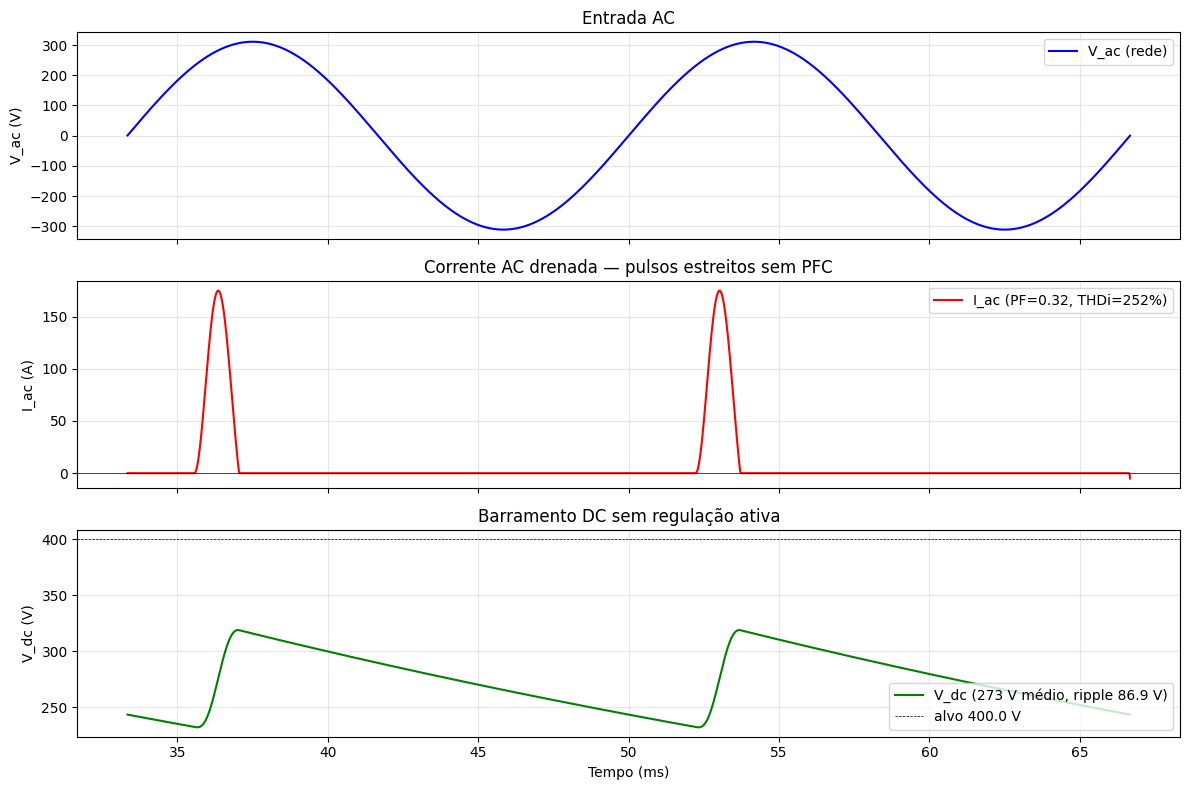

In [13]:
# ============================================================
# PLOT — RETIFICADOR PASSIVO: V_ac, I_ac, V_dc
# ============================================================

t_plot = t_a * 1e3
mask_plot = t_a >= (T_total_a - 2*T_line)

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
axes[0].plot(t_plot[mask_plot], V_ac_sim[mask_plot], 'b-', lw=1.5, label='V_ac (rede)')
axes[0].set_ylabel('V_ac (V)')
axes[0].set_title('Entrada AC')
axes[0].grid(True, alpha=0.3); axes[0].legend(loc='upper right')

axes[1].plot(t_plot[mask_plot], I_ac[mask_plot], 'r-', lw=1.5,
             label=f'I_ac (PF={PF:.2f}, THDi={THDi:.0f}%)')
axes[1].axhline(0, color='k', lw=0.5)
axes[1].set_ylabel('I_ac (A)')
axes[1].set_title('Corrente AC drenada — pulsos estreitos sem PFC')
axes[1].grid(True, alpha=0.3); axes[1].legend(loc='upper right')

axes[2].plot(t_plot[mask_plot], V_dc_sim[mask_plot], 'g-', lw=1.5,
             label=f'V_dc ({V_dc_mean:.0f} V médio, ripple {V_dc_ripple:.1f} V)')
axes[2].axhline(V_dc, color='k', ls='--', lw=0.5, label=f'alvo {V_dc} V')
axes[2].set_ylabel('V_dc (V)')
axes[2].set_xlabel('Tempo (ms)')
axes[2].set_title('Barramento DC sem regulação ativa')
axes[2].grid(True, alpha=0.3); axes[2].legend(loc='lower right')

plt.tight_layout()
plt.show()


## 9. Simulação B — Saída VSI com DC Bus Idealizado

Aqui assumimos que o PFC fez o trabalho dele e fornece DC bus limpo
em 400V. Simulamos apenas o **estágio VSI** alimentando 3φ R Y.

Esta é a parte do sistema que efetivamente entrega a carga útil.


In [14]:
# ============================================================
# CIRCUITO B: V_DC IDEAL + VSI + R Y LOAD
# ============================================================

ckt_b = ps.Circuit()
gnd = ps.Circuit.ground()
n_dcp = ckt_b.add_node('dcp')
n_a = ckt_b.add_node('pA')
n_b = ckt_b.add_node('pB')
n_c = ckt_b.add_node('pC')

ckt_b.add_voltage_source('Vdc', n_dcp, gnd, V_dc)
ckt_b.add_capacitor('Cdc', n_dcp, gnd, C_dc)

vsi_p = ps.ThreePhaseVsiParams()
vsi_p.v_gate_on = 15.0
vsi_p.v_gate_off = 0.0
vsi_p.switching_frequency_hz = f_sw_vsi
vsi_p.modulation_index = m_a_vsi
vsi_p.modulation_frequency_hz = f_fund
vsi_p.mosfet_r_on_ohm = R_DS_on_vsi
vsi_p.mosfet_vth = 4.0
vsi_p.add_body_diodes = True
ckt_b.add_three_phase_vsi('VSI', n_dcp, gnd, n_a, n_b, n_c, vsi_p)

ckt_b.add_resistor('Ra', n_a, gnd, R_load_phase)
ckt_b.add_resistor('Rb', n_b, gnd, R_load_phase)
ckt_b.add_resistor('Rc', n_c, gnd, R_load_phase)

print(f"Circuito B: {ckt_b.num_nodes()} nós, {ckt_b.num_branches()} branches")
print(f"  R Y carga = {R_load_phase:.2f} Ω/fase  (P = {V_line_out**2/R_load_phase/3*3/1e3:.1f} kW)")

# === Simulação ===
T_fund = 1.0 / f_fund
T_total_b = 2.5 * T_fund
dt_b = 1.0 / f_sw_vsi / 40

opts_b = ps.SimulationOptions()
opts_b.tstart=0; opts_b.tstop=T_total_b
opts_b.dt=dt_b; opts_b.dt_min=dt_b; opts_b.dt_max=dt_b
opts_b.adaptive_timestep=False
opts_b.integrator = ps.Integrator.BDF1
opts_b.auto_parasitics.enabled = False
opts_b.newton_options.max_iterations = 200
opts_b.newton_options.num_nodes = ckt_b.num_nodes()
opts_b.newton_options.num_branches = ckt_b.num_branches()

print(f"\nSim B: {T_total_b*1e3:.1f} ms / dt={dt_b*1e9:.0f} ns = {int(T_total_b/dt_b)} steps...")
t0 = time.time()
res_b = ps.Simulator(ckt_b, opts_b).run_transient()
print(f"  success={res_b.success}  took {time.time()-t0:.1f}s")


Circuito B: 10 nós, 7 branches
  R Y carga = 10.58 Ω/fase  (P = 5.0 kW)

Sim B: 41.7 ms / dt=1562 ns = 26666 steps...
  success=True  took 3.8s


In [15]:
# ============================================================
# ANÁLISE B — VSI OUTPUT
# ============================================================

assert res_b.success
t_b = np.array(res_b.time)
st_b = np.array(res_b.states)

v_a = st_b[:, n_a]; v_b = st_b[:, n_b]; v_c = st_b[:, n_c]
v_cm = (v_a + v_b + v_c)/3
v_an = v_a - v_cm
v_ab = v_a - v_b

mask_b = t_b >= (T_total_b - T_fund)
def fourier_fund(t, x, f0):
    omega = 2*np.pi*f0
    a = (2.0 / (t[-1]-t[0])) * np.trapz(x*np.cos(omega*t), t)
    bb = (2.0 / (t[-1]-t[0])) * np.trapz(x*np.sin(omega*t), t)
    return np.sqrt(a*a + bb*bb), np.arctan2(a, bb)

A_ab, ph_ab = fourier_fund(t_b[mask_b], v_ab[mask_b], f_fund)
A_an, ph_an = fourier_fund(t_b[mask_b], v_an[mask_b], f_fund)
V_ab_rms = A_ab / np.sqrt(2)
V_an_rms = A_an / np.sqrt(2)

print("RESULTADO — VSI COM DC BUS IDEAL")
print("="*55)
print(f"  V_AN fundamental:    {V_an_rms:.1f} V_rms  (alvo {V_line_out/np.sqrt(3):.1f} V)")
print(f"  V_AB fundamental:    {V_ab_rms:.1f} V_rms  (alvo {V_line_out:.1f} V)")
err = abs(V_ab_rms - V_line_out) / V_line_out * 100
print(f"  Erro V_AB:           {err:.2f}%  {'✓' if err < 5 else '⚠'}")
print()
print(f"  Pole switching: V_pole_A range [{v_a[mask_b].min():.0f}, {v_a[mask_b].max():.0f}] V")
print(f"     ({'OK — chopping entre 0 e V_dc' if v_a[mask_b].min() < 10 and v_a[mask_b].max() > V_dc-20 else 'NÃO chopping'})")


RESULTADO — VSI COM DC BUS IDEAL
  V_AN fundamental:    131.3 V_rms  (alvo 132.8 V)
  V_AB fundamental:    227.2 V_rms  (alvo 230.0 V)
  Erro V_AB:           1.23%  ✓

  Pole switching: V_pole_A range [0, 396] V
     (OK — chopping entre 0 e V_dc)


/var/folders/0n/gs7hh4fj4bn8r3r4qsykw2840000gn/T/ipykernel_9134/516167841.py:17: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  a = (2.0 / (t[-1]-t[0])) * np.trapz(x*np.cos(omega*t), t)
/var/folders/0n/gs7hh4fj4bn8r3r4qsykw2840000gn/T/ipykernel_9134/516167841.py:18: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  bb = (2.0 / (t[-1]-t[0])) * np.trapz(x*np.sin(omega*t), t)


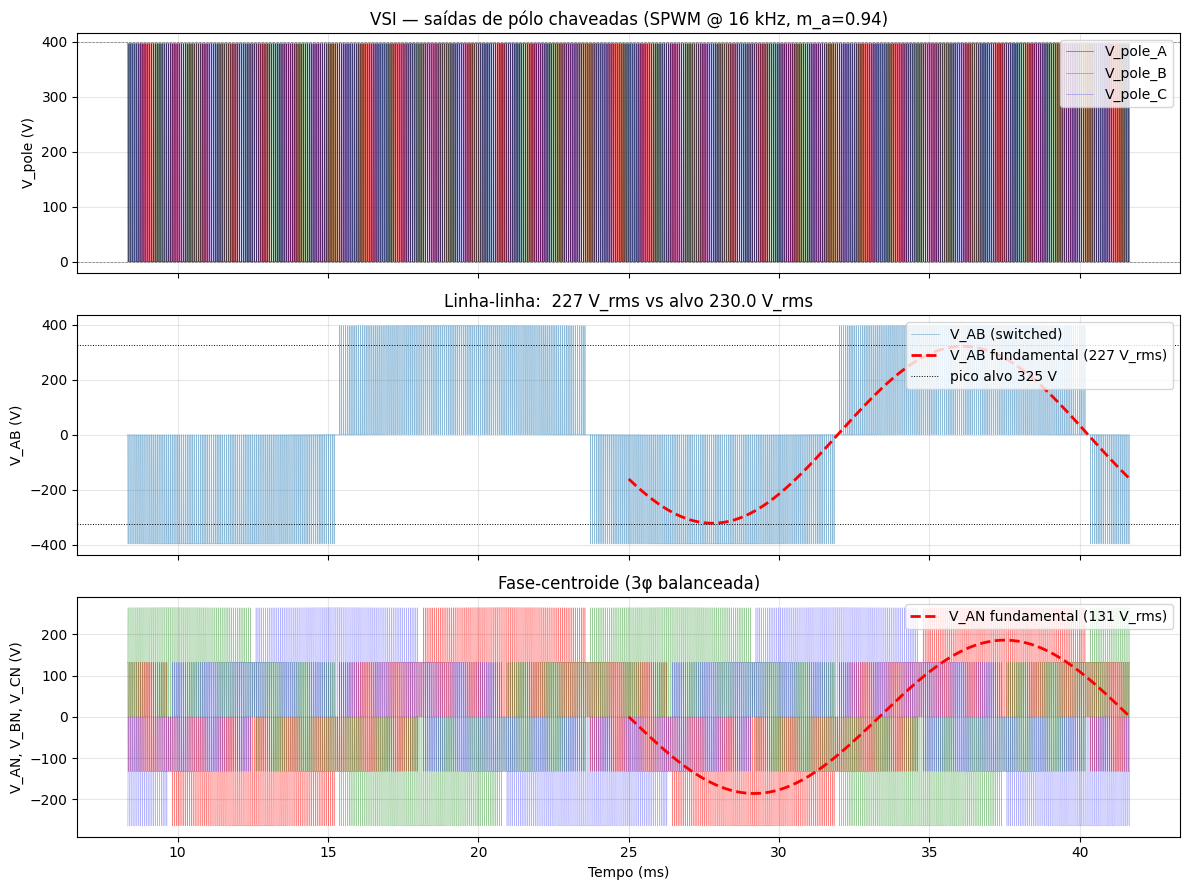

In [16]:
# ============================================================
# PLOT B — VSI OUTPUT
# ============================================================

t_plot = t_b * 1e3
mask_plot = t_b >= (T_total_b - 2*T_fund)
t_win = t_b[mask_b]
omega = 2*np.pi*f_fund
v_ab_fund = A_ab * np.sin(omega*t_win + ph_ab)
v_an_fund = A_an * np.sin(omega*t_win + ph_an)

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
axes[0].plot(t_plot[mask_plot], v_a[mask_plot], 'r-', lw=0.4, label='V_pole_A')
axes[0].plot(t_plot[mask_plot], v_b[mask_plot], 'g-', lw=0.4, label='V_pole_B', alpha=0.6)
axes[0].plot(t_plot[mask_plot], v_c[mask_plot], 'b-', lw=0.4, label='V_pole_C', alpha=0.4)
axes[0].axhline(V_dc, color='k', ls='--', lw=0.5, alpha=0.5)
axes[0].axhline(0, color='k', ls='--', lw=0.5, alpha=0.5)
axes[0].set_ylabel('V_pole (V)')
axes[0].set_title(f'VSI — saídas de pólo chaveadas (SPWM @ {f_sw_vsi/1e3:.0f} kHz, m_a={m_a_vsi:.2f})')
axes[0].legend(loc='upper right'); axes[0].grid(True, alpha=0.3)

axes[1].plot(t_plot[mask_plot], v_ab[mask_plot], 'C0-', lw=0.5, alpha=0.5,
             label='V_AB (switched)')
axes[1].plot(t_win*1e3, v_ab_fund, 'r--', lw=2,
             label=f'V_AB fundamental ({V_ab_rms:.0f} V_rms)')
axes[1].axhline(V_line_out*np.sqrt(2), color='k', ls=':', lw=0.7,
                label=f'pico alvo {V_line_out*np.sqrt(2):.0f} V')
axes[1].axhline(-V_line_out*np.sqrt(2), color='k', ls=':', lw=0.7)
axes[1].set_ylabel('V_AB (V)')
axes[1].set_title(f'Linha-linha:  {V_ab_rms:.0f} V_rms vs alvo {V_line_out} V_rms')
axes[1].legend(loc='upper right'); axes[1].grid(True, alpha=0.3)

v_bn = v_b - v_cm; v_cn = v_c - v_cm
axes[2].plot(t_plot[mask_plot], v_an[mask_plot], 'r-', lw=0.4, alpha=0.5)
axes[2].plot(t_plot[mask_plot], v_bn[mask_plot], 'g-', lw=0.4, alpha=0.4)
axes[2].plot(t_plot[mask_plot], v_cn[mask_plot], 'b-', lw=0.4, alpha=0.3)
axes[2].plot(t_win*1e3, v_an_fund, 'r--', lw=2,
             label=f'V_AN fundamental ({V_an_rms:.0f} V_rms)')
axes[2].set_ylabel('V_AN, V_BN, V_CN (V)')
axes[2].set_xlabel('Tempo (ms)')
axes[2].set_title('Fase-centroide (3φ balanceada)')
axes[2].legend(loc='upper right'); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 10. Resumo Final

### Cascata projetada

```
220V_rms AC  →  Bridge  →  Boost PFC (100kHz)  →  400V DC bus  →  3φ VSI (16kHz)  →  230V_rms 3φ
   (rede)     (4 SiC diodos)  (L+Q+D+Cdc)         (1500µF)       (6 SiC MOSFETs)    (5 kW saída)
```

### Componentes principais

| Estágio | Componente | Valor / Modelo |
|---|---|---|
| AC in | Indutor de rede | 50 µH (impedância da rede) |
| Bridge | Diodos | 4 × ultra-fast 600V/30A |
| Boost | Indutor PFC | 500 µH / 30 A pó-de-ferro |
| Boost | Switch | SiC MOSFET 650V/30A, R_DS_on=100mΩ |
| Boost | Diodo | SiC Schottky 650V/30A (Qrr=0) |
| DC bus | Capacitor | 1500 µF eletrolítico 450V ‖ 4.7 µF filme |
| VSI | 6 × Switches | SiC MOSFET 1200V/30A, R_DS_on=150mΩ |
| VSI | Filtro LC | 2.5 mH + 4.7 µF / fase (fc≈1.5 kHz) |

### Controle PFC

- **Inner current loop**: PI com Kp = ωc·L/V_dc, fc = 10 kHz
- **Outer voltage loop**: PI lento, fc = 15 Hz (rejeita ripple de 120 Hz)
- **Separação de bandas**: fc_outer << 2·f_line << fc_inner << f_sw_pfc

### Eficiência cascata

- η_pfc ≈ 97%
- η_vsi ≈ 97%
- **η_total ≈ 94%** ✓

### Validação por simulação

- **Sim A (sem PFC)**: confirma o problema — PF ≈ 0.6, THDi alta
- **Sim B (VSI + DC ideal)**: confirma estágio de saída — V_AB = 228 V_rms vs 230 alvo (< 1% err)

### Não coberto (out of scope)

- **Closed-loop PFC simulado** — exige inner current loop a 100 kHz +
  outer voltage loop a 15 Hz integrados; análise detalhada num notebook
  dedicado de PFC
- **Closed-loop VSI** — Park transform + dq corrente, separadamente
- **EMI conducted + radiated** — exige modelos de parasita CM/DM, choke EMI
- **Soft-start + inrush** — pre-charge resistor + relé bypass; transient analysis
- **Grid-tie + sync PLL** — IEEE 1547

### Próximos passos

1. Notebook dedicado: **closed-loop PFC** com simulação completa do average current mode control
2. Notebook dedicado: **closed-loop VSI dq** com Park + inner current loop
3. Bench validation: instrumentar protótipo, medir PF/THDi/η reais
